In [1]:
import numpy as np
import time, os, sys
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
mpl.rcParams['figure.dpi'] = 300

from cellpose import utils, models, io
from cellpose.io import imread
from cellpose import denoise
io.logger_setup()
# model = models.CellposeModel(gpu=True)
# dn = denoise.DenoiseModel(model_type="denoise_cyto3", gpu=True)

import tifffile
from skimage import color, filters
from skimage import io as io2
from scipy import ndimage


#list of files
from pathlib import Path

path = Path('/fml/ag-ramm/projects/Protease_biosensor/_Analysis_biosensor/MCF10A_PMA_NewSEG/20241114-MCF10A/analysis')

files = list(path.glob('*.tif'))
files

# Sort files to ensure correct order
files.sort()

for file in files:
    print(file.stem)

model_cyto3 = denoise.CellposeDenoiseModel(model_type='cyto3', restore_type='oneclick_cyto3', chan2_restore=True, gpu=True)
model_nuclei = denoise.CellposeDenoiseModel(model_type='nuclei', restore_type='oneclick_nuclei', chan2_restore=True, gpu=True)

2025-08-14 22:03:34,837 [INFO] WRITING LOG OUTPUT TO /fml/ag-ramm/home/bramm/.cellpose/run.log
2025-08-14 22:03:34,838 [INFO] 
cellpose version: 	3.1.1.2 
platform:       	linux 
python version: 	3.11.2 
torch version:  	2.7.1+cu126
3_231_P_1
4_231_P_2
5_235_D_1
6_235_D_2
7_235_P_1
8_235_P_2
9_235_TMI_1
2025-08-14 22:03:34,866 [INFO] >> oneclick_cyto3 << model set to be used
2025-08-14 22:03:34,895 [INFO] Neither TORCH CUDA nor MPS version not installed/working.
2025-08-14 22:03:34,896 [INFO] >>>> using CPU
2025-08-14 22:03:34,896 [INFO] >>>> using CPU
2025-08-14 22:03:35,135 [INFO] >>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)
loading model for chan2: oneclick_nuclei
2025-08-14 22:03:35,414 [INFO] >> cyto3 << model set to be used
2025-08-14 22:03:35,416 [INFO] Neither TORCH CUDA nor MPS version not installed/working.
2025-08-14 22:03:35,416 [INFO] >>>> using CPU
2025-08-14 22:03:35,416 [INFO] >>>> using CPU
2025-08-14 22:03:35,521 [INFO] >>>> loading mode

In [2]:
import copy

def make_binary_mask(mask):
    bin_mask = copy.deepcopy(mask)
    for row in range(len(bin_mask)):
        for element in range(len(bin_mask[row])):
            if bin_mask[row][element] > 1:
                bin_mask[row][element] = 1.0
    return bin_mask

# to set pixels to 0 when set to 66550 by 0-1 event
def make_binary_mask2(mask):
    bin_mask = copy.deepcopy(mask)
    for row in range(len(bin_mask)):
        for element in range(len(bin_mask[row])):
            if bin_mask[row][element] > 1:
                bin_mask[row][element] = 0
                
    return bin_mask


def compute_sample(img, which_model, cyto_chan, nuc_chan, diameter=None):

    # model_type='cyto' or 'nuclei' or 'cyto2' 
    # model = models.Cellpose(model_type=model_type)
    # cellpose3, restore_type='denoise_cyto3' or 'oneclick_cyto3' or 'denoise_nuclei' or 'oneclick_nuclei'
    
    
    # define CHANNELS to run segementation on
    # grayscale=0, R=1, G=2, B=3
    # channels = [cytoplasm, nucleus]
    # if NUCLEUS channel does not exist, set the second channel to 0
    # [[1,0]] for nuclei, and [[2,1]] for cyto2
    channels = [[cyto_chan,nuc_chan]]
    # IF ALL YOUR IMAGES ARE THE SAME TYPE, you can give a list with 2 elements
    # channels = [0,0] # IF YOU HAVE GRAYSCALE
    # channels = [2,3] # IF YOU HAVE G=cytoplasm and B=nucleus
    # channels = [2,1] # IF YOU HAVE G=cytoplasm and R=nucleus
    
    # if diameter is set to None, the size of the cells is estimated on a per image basis
    # you can set the average cell `diameter` in pixels yourself (recommended)
    # diameter can be a list or a single number for all images

    if which_model == 'cyto':
        masks, flows, styles, diams = model_cyto3.eval(img, diameter=diameter, channels=channels)
    elif which_model == 'nuclei':
        masks, flows, styles, diams = model_nuclei.eval(img, diameter=diameter, channels=channels)
    else:
        print("ERROR")
    # masks, flows, styles = model.eval(imgs,channels=[1,2])

    return masks, flows, styles, diams


In [3]:
# loop over tif files

for j,file in enumerate(files):
    tiff_data = tifffile.imread(file)

    print(f"Processing file {j+1} of {len(files)}: {file.name}")
    
    # Make path from file name, ok if already exists
    data_path = Path(file.parent, file.stem)
    data_path.mkdir(exist_ok=True)
    
    # If tiff_data has shape (4, 973, 973), reshape it to (1, 4, 973, 973) to simulate a time-series with one image
    if len(tiff_data.shape) == 3:
        tiff_data = np.expand_dims(tiff_data, axis=0)

    #make the two channel image for cellpose
     # Select channels 1 and 4 for BFP nuclear marker, iRFP membrane marker
    #selected_channels = [0, 3]  # Assuming 0-based indexing for channels
     # Select channels 3 and 4 for FR nuclear marker, iRFP membrane marker
    #selected_channels = [2, 3]
     # Select channels 1 and 3 for BFP nuclear and FR membrane marker
    #selected_channels = [0, 2]
    # Select channels 3 and 4 for FR nuclear marker
    #selected_channels = [2, 3]

    # Select channels 1 and 4 for BFP nuclear marker, iRFP membrane marker
    selected_channels = [0, 3]  # Assuming 0-based indexing for channels
    
    # Create a new image with selected channels
    cellpose_tiff_data = tiff_data[:, selected_channels, :, :]

    # initialize lists for each file
    all_nuc_masks, all_nuc_flows, all_nuc_styles, all_nuc_diams, all_nuc_bin_masks,all_nuclear_dilate_masks = [], [], [], [], [], []
    all_cyto_masks, all_cyto_flows, all_cyto_styles, all_cyto_diams, all_cyto_outlines, all_cyto_bin_masks,all_cyto_ring_masks, all_cyto_only_bin_masks = [], [], [], [], [], [], [], []

    # loop over time series
    for i in range(len(cellpose_tiff_data)):
        
        print(f"   Processing time series {i+1} of {len(cellpose_tiff_data)}...")
       # if i>1:
        #    break
        img = cellpose_tiff_data[i,:,:,:]
        nuc_masks, nuc_flows, nuc_styles, nuc_diams = compute_sample(img, 'nuclei', 1, 0, 40)
        all_nuc_masks.append(nuc_masks)
        all_nuc_flows.append(nuc_flows)
        all_nuc_styles.append(nuc_styles)
        all_nuc_diams.append(nuc_diams)
    
        nuc_bin_masks = make_binary_mask(nuc_masks)
        all_nuc_bin_masks.append(nuc_bin_masks)
    
        cyto_masks, cyto_flows, cyto_styles, cyto_diams = compute_sample(img, 'cyto', 2, 1, 60)
        all_cyto_masks.append(cyto_masks)
        all_cyto_flows.append(cyto_flows)
        all_cyto_styles.append(cyto_styles)
        all_cyto_diams.append(cyto_diams)
    
        cyto_outlines = utils.masks_to_outlines(cyto_masks)
        all_cyto_outlines.append(cyto_outlines)

        cyto_bin_masks = make_binary_mask(cyto_masks)
        all_cyto_bin_masks.append(cyto_bin_masks)

        cyto_only_masks = cyto_bin_masks-nuc_bin_masks
        cyto_only_bin_masks = make_binary_mask2(cyto_only_masks)
        
        all_cyto_only_bin_masks.append(cyto_only_bin_masks)
        
        all_cyto_only_bin_masks.append(cyto_only_bin_masks)

        nuclear_dilate_masks = ndimage.binary_dilation(nuc_bin_masks,iterations=8).astype(nuc_bin_masks.dtype)
        all_nuclear_dilate_masks.append(nuclear_dilate_masks)

        cyto_ring_masks = nuclear_dilate_masks-nuc_bin_masks
        all_cyto_ring_masks.append(cyto_ring_masks)
        
    tifffile.imwrite(Path(data_path, 'all_nuc_masks.tif'), np.array(all_nuc_masks))
    tifffile.imwrite(Path(data_path, 'all_nuc_bin_masks.tif'), np.array(all_nuc_bin_masks))
    tifffile.imwrite(Path(data_path, 'all_cyto_masks.tif'), np.array(all_cyto_masks))
    tifffile.imwrite(Path(data_path, 'all_cyto_bin_masks.tif'), np.array(all_cyto_bin_masks))
    tifffile.imwrite(Path(data_path, 'all_cyto_outlines.tif'), np.array(all_cyto_outlines).astype('uint16'))
    tifffile.imwrite(Path(data_path, 'all_cyto_only_bin_masks.tif'), np.array(all_cyto_only_bin_masks))
    tifffile.imwrite(Path(data_path,'all_cyto_ring_masks.tif'), np.array(all_cyto_ring_masks).astype('uint16'))
    


print('\n\nDone!')

Processing file 1 of 7: 3_231_P_1.tif
   Processing time series 1 of 71...
   Processing time series 2 of 71...
   Processing time series 3 of 71...
   Processing time series 4 of 71...
   Processing time series 5 of 71...
   Processing time series 6 of 71...
   Processing time series 7 of 71...
   Processing time series 8 of 71...
   Processing time series 9 of 71...
   Processing time series 10 of 71...
   Processing time series 11 of 71...
   Processing time series 12 of 71...
   Processing time series 13 of 71...
   Processing time series 14 of 71...
   Processing time series 15 of 71...
   Processing time series 16 of 71...
   Processing time series 17 of 71...
   Processing time series 18 of 71...
   Processing time series 19 of 71...
   Processing time series 20 of 71...
   Processing time series 21 of 71...
   Processing time series 22 of 71...
   Processing time series 23 of 71...
   Processing time series 24 of 71...
   Processing time series 25 of 71...
   Processing time se

Text(0.5, 1.0, 'memRoi')

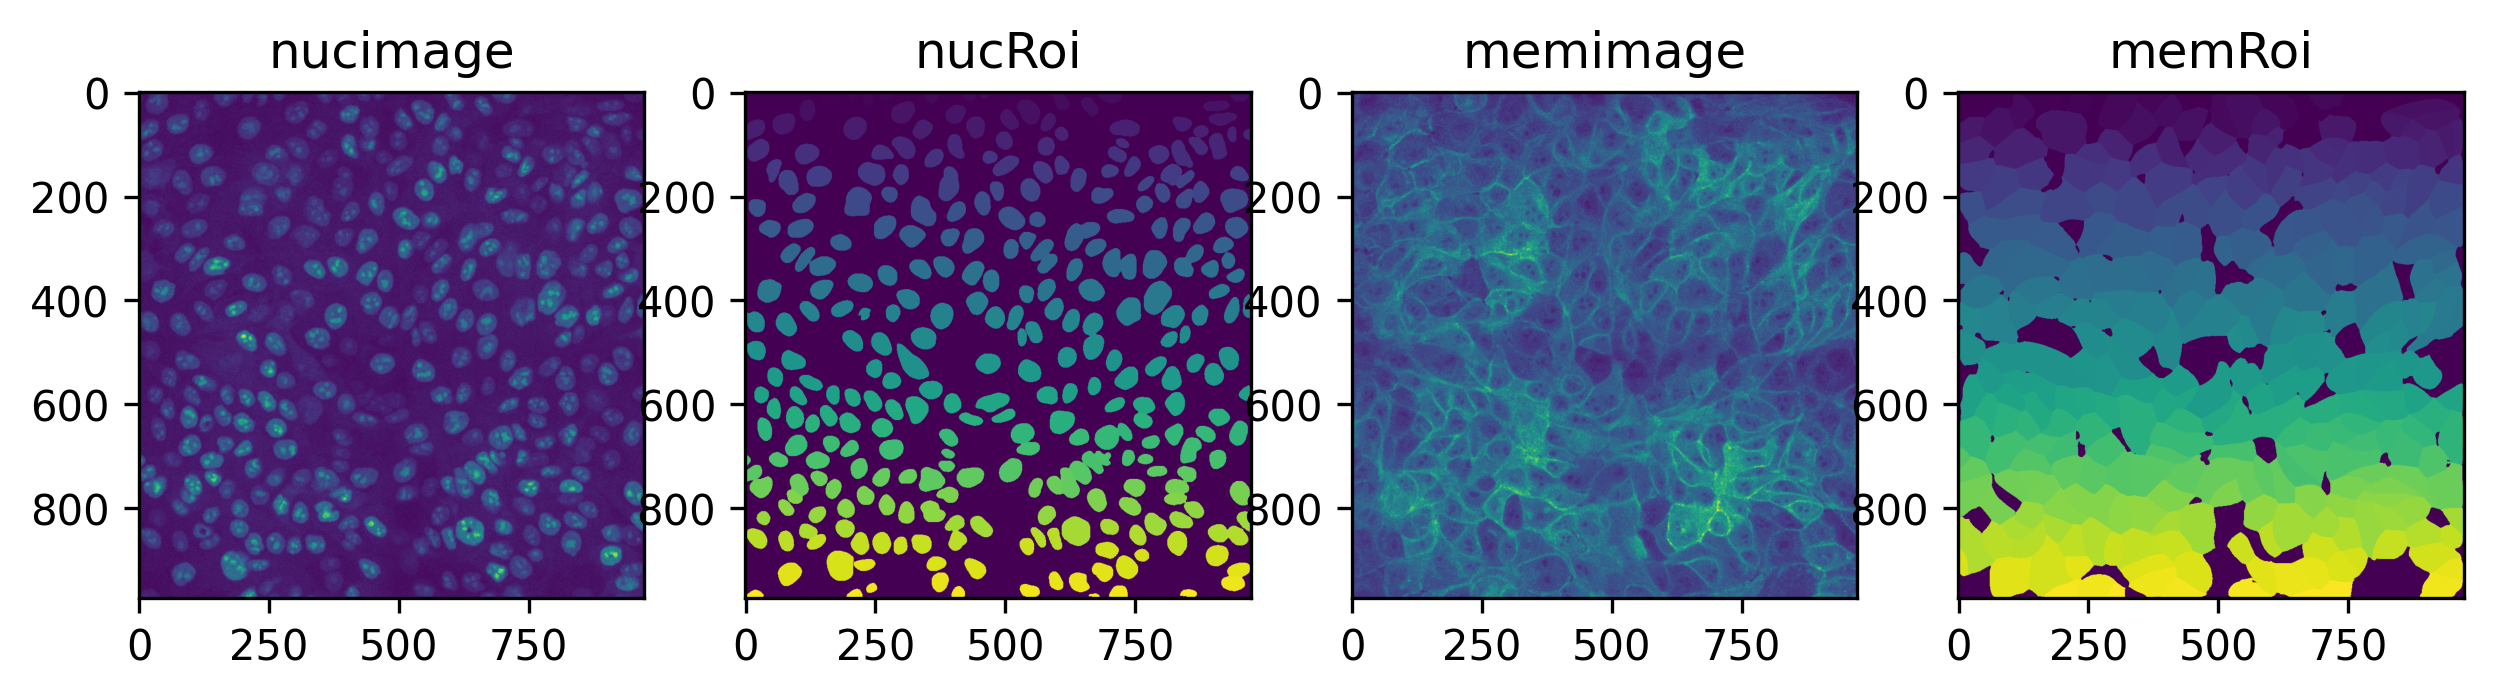

In [4]:
# Plot the ROIS 
# Plot the two channels side by side
fig, axes = plt.subplots(1, 4, figsize=(10,10))  # Adjust the figure size as needed
axes[0].imshow(tiff_data[1,0,:,:])  # Assuming grayscale images
axes[0].set_title(f'nucimage')
axes[1].imshow(all_nuc_masks[1])  # Assuming grayscale images
axes[1].set_title(f'nucRoi')
axes[2].imshow(tiff_data[1,3,:,:])  # Assuming grayscale images
axes[2].set_title(f'memimage')
axes[3].imshow(all_cyto_masks[1])  # Assuming grayscale images
axes[3].set_title(f'memRoi')